<h1 style="text-align: center;">COVID-19 Spread Analysis</h1> 
The client requires a report on COVID-19 cases and vaccinations across different regions of the world.

For this purpose, the analysis uses data collected and maintained by Our World in Data (see https://github.com/owid/covid-19-data/tree/master/public/data).

The dataset can be downloaded directly from the platform or through the following link:
https://raw.githubusercontent.com/owid/covid-19-data/refs/heads/master/public/data/owid-covid-data.csv 

### 1. Check the dataset dimensions and its associated metadata.

In [1]:
# Import libraries and dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

covid_database = pd.read_csv("https://raw.githubusercontent.com/owid/covid-19-data/refs/heads/master/public/data/owid-covid-data.csv")

# Save the dataset locally
covid_database.to_csv("covid_database.csv", index=False)

# Further information:
# https://github.com/owid/covid-19-data/blob/master/public/data/README.md

In [2]:
# Check the dataset dimensions and metadata
covid_database.shape #(429435 righe, 67 colonne)
covid_database.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 429435 entries, 0 to 429434
Data columns (total 67 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   iso_code                                    429435 non-null  object 
 1   continent                                   402910 non-null  object 
 2   location                                    429435 non-null  object 
 3   date                                        429435 non-null  object 
 4   total_cases                                 411804 non-null  float64
 5   new_cases                                   410159 non-null  float64
 6   new_cases_smoothed                          408929 non-null  float64
 7   total_deaths                                411804 non-null  float64
 8   new_deaths                                  410608 non-null  float64
 9   new_deaths_smoothed                         409378 non-null  float64
 

In [3]:
#Preview of the database
covid_database.head()

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2020-01-06,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2020-01-07,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
3,AFG,Asia,Afghanistan,2020-01-08,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
4,AFG,Asia,Afghanistan,2020-01-09,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN


In [4]:
# Check and count missing values
covid_database.isna().sum()

iso_code                                        0
continent                                   26525
location                                        0
date                                            0
total_cases                                 17631
                                            ...  
population                                      0
excess_mortality_cumulative_absolute       416024
excess_mortality_cumulative                416024
excess_mortality                           416024
excess_mortality_cumulative_per_million    416024
Length: 67, dtype: int64

In [5]:
# Analyze the dataset to understand the differences between the "continent" and "location" columns
covid_database[["continent","location"]][2500:5000]

pd.options.display.max_rows = 999
covid_database[1673:1675]

# Analyze the dataset to understand the differences between the "new_cases" and "total_cases" columns
afghanistan = covid_database[covid_database["location"]=="Afghanistan"]
new_cases_afg = afghanistan["new_cases"].sum()
print(f"Afghanistan: {new_cases_afg}")

afghanistan = covid_database[covid_database["location"]=="Afghanistan"]
total_cases_afg = afghanistan["total_cases"].max()
print(f"Afghanistan: {total_cases_afg}")

Afghanistan: 235214.0
Afghanistan: 235214.0


In [6]:
# Check whether the sum of "new_cases" for each country matches the latest "total_cases" value
somma_new_cases = covid_database.groupby("location")["new_cases"].sum()
continents = covid_database["continent"].dropna().unique().tolist() 
total_cases = covid_database.groupby("continent")["total_cases"].max()

somma_new_cases_continenti = somma_new_cases[somma_new_cases.index.isin(continents)]

confronto = pd.DataFrame({
    "total_cases": total_cases,
    "somma_new_cases": somma_new_cases_continenti
})
confronto
#location_to_continent = somma_new_cases.set_index("location")["continent"]
#somma_new_cases_con_continente = somma_new_cases.to_frame().join(location_to_continent, how="left")
#somma_new_cases_con_continente
#print(somma_new_cases_continent)
#print(total_cases)
#confronto = [somma_new_cases & total_cases]


,total_cases,somma_new_cases
Africa,4072765.0,13146831.0
Asia,99373219.0,301564180.0
Europe,38997490.0,252916868.0
North America,103436829.0,124492698.0
Oceania,11861161.0,15003468.0
South America,37511921.0,68811012.0


In [7]:
# Identify the continents
covid_database["continent"].unique() #'Asia', nan, 'Europe', 'Africa', 'Oceania', 'North America','South America'

array(['Asia', nan, 'Europe', 'Africa', 'Oceania', 'North America',
       'South America'], dtype=object)

In [8]:
# Identify the locations
locations = covid_database["location"].unique() 
locations

array(['Afghanistan', 'Africa', 'Albania', 'Algeria', 'American Samoa',
       'Andorra', 'Angola', 'Anguilla', 'Antigua and Barbuda',
       'Argentina', 'Armenia', 'Aruba', 'Asia', 'Australia', 'Austria',
       'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh', 'Barbados',
       'Belarus', 'Belgium', 'Belize', 'Benin', 'Bermuda', 'Bhutan',
       'Bolivia', 'Bonaire Sint Eustatius and Saba',
       'Bosnia and Herzegovina', 'Botswana', 'Brazil',
       'British Virgin Islands', 'Brunei', 'Bulgaria', 'Burkina Faso',
       'Burundi', 'Cambodia', 'Cameroon', 'Canada', 'Cape Verde',
       'Cayman Islands', 'Central African Republic', 'Chad', 'Chile',
       'China', 'Colombia', 'Comoros', 'Congo', 'Cook Islands',
       'Costa Rica', "Cote d'Ivoire", 'Croatia', 'Cuba', 'Curacao',
       'Cyprus', 'Czechia', 'Democratic Republic of Congo', 'Denmark',
       'Djibouti', 'Dominica', 'Dominican Republic', 'East Timor',
       'Ecuador', 'Egypt', 'El Salvador', 'England', 'Equatorial Guine

### 2. For each continent, calculate:
        a. the total number of cases recorded since the beginning of the pandemic

In [9]:
#per continent

print("Verification of the total number of cases recorded in each continent since the beginning of the pandemic:")
num_tot_mondo = 0
continents = covid_database["continent"].dropna().unique().tolist() 
continents.sort()
print(continents)

for continent in continents:
    num_tot_continent = covid_database[covid_database["continent"] == continent]["new_cases"].sum()
    print(f"{continent}: {num_tot_continent}")
    

Verification of the total number of cases recorded in each continent since the beginning of the pandemic:
['Africa', 'Asia', 'Europe', 'North America', 'Oceania', 'South America']
Africa: 13146831.0
Asia: 301564180.0
Europe: 252916868.0
North America: 124492698.0
Oceania: 15003468.0
South America: 68811012.0


### 2. For each continent, calculate:
        a. the percentage of cases in each continent relative to the global total:

Africa: 1.69%
Asia: 38.86%
Europe: 32.6%
North America: 16.04%
Oceania: 1.93%
South America: 8.87%


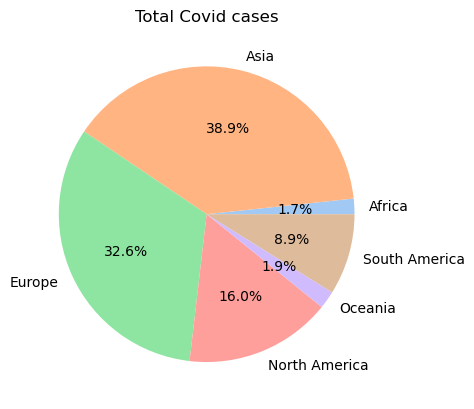

In [10]:
percentages = []
num_tot_mondo = covid_database[covid_database["location"] == "World"]["new_cases"].sum()

for continent in continents:
    num_tot_continent = covid_database[covid_database["continent"]==continent]["new_cases"].sum()
    percentage_continent = round((num_tot_continent / num_tot_mondo * 100), 2)
    
    percentages.append(percentage_continent)
    print(f"{continent}: {percentage_continent}%")


plt.pie(percentages, labels= continents, colors=sns.color_palette('pastel'), autopct='%1.1f%%')
plt.title("Total Covid cases")
plt.show()

### 3. Select the data for Italy in 2022. Since new cases are recorded weekly, filter out the days without measurements. Then, show:
        a. The evolution of total cases from the beginning to the end of the year....

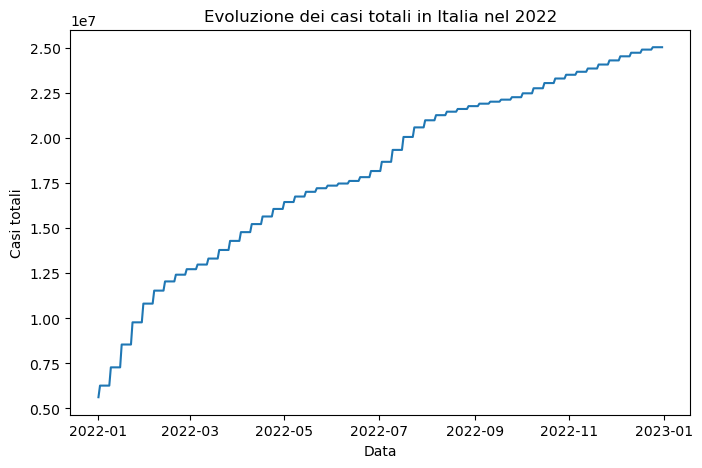

25060503.0

In [11]:
import time
import seaborn as sns
import matplotlib.pyplot as plt

# Check the format of the date column
covid_database["date"].dtype # The column is not in datetime format

# Convert the entire column to datetime
covid_database["date"] = pd.to_datetime(covid_database["date"])

# Extract the year into a separate column
covid_database["year"] = covid_database["date"].dt.year

# Filter the data for Italy
italia = covid_database[covid_database["location"]=="Italy"]

# italia["date"].info()  # dtype: datetime64[ns] — OK

# italia["date"].isna().sum()  # No missing values

# Remove missing values from "new_cases" and filter the data for 2022

italia_2022_pulito = italia[(italia["year"] == 2022) & (italia["new_cases"].notna())]

italia_2022_pulito.to_csv("italia_2022_pulito.csv", index=False)

# Plot the evolution of total cases
plt.figure(figsize=(8,5))

grafico = sns.lineplot(data = italia_2022_pulito, x = "date", y = "total_cases")
plt.title("Evoluzione dei casi totali in Italia nel 2022")
plt.xlabel("Data")
plt.ylabel("Casi totali")

plt.show()

italia_2022_pulito["total_cases"].max()

### 3. Select the data for Italy in 2022. Since new cases are recorded weekly, filter out the days without measurements. Then, show:
        a. The number of new cases over time:

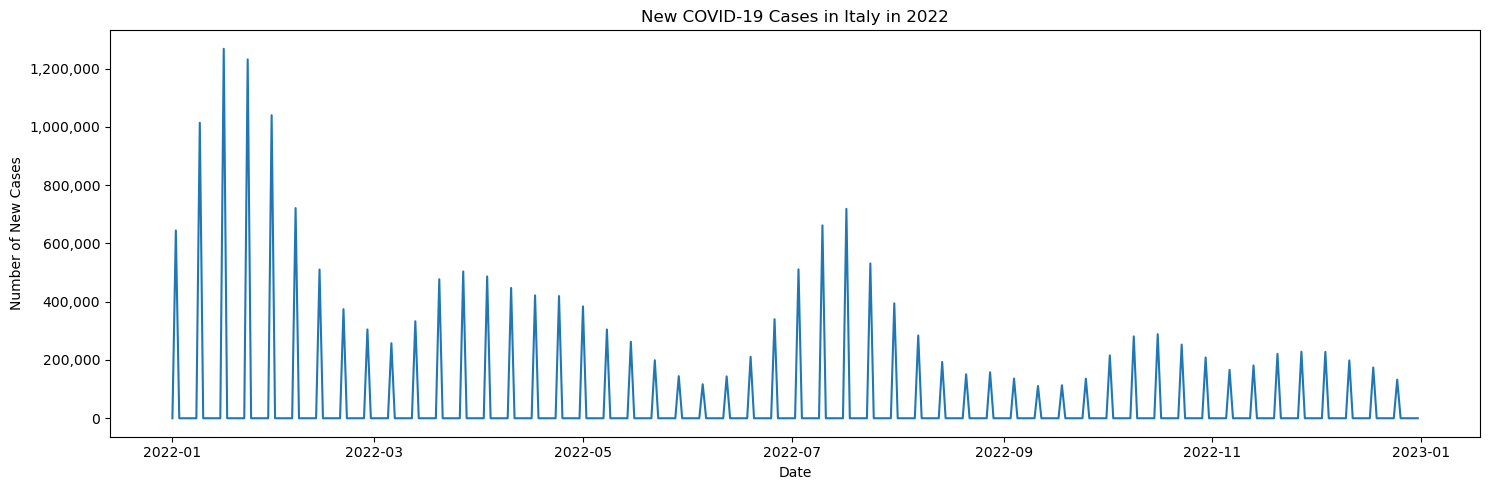

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Plot the number of new cases
plt.figure(figsize=(15, 5))

grafico = sns.lineplot(
    data=italia_2022_pulito,
    x="date",
    y="new_cases"
)

plt.title("New COVID-19 Cases in Italy in 2022")
plt.xlabel("Date")
plt.ylabel("Number of New Cases")

grafico.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x:,.0f}")
)

plt.tight_layout()
plt.show()

### 4. For Italy, Germany, and France:
        a. compare the number of intensive care unit (ICU) patients across the three countries, using the icu_patients column, from May 2022 through April 2023, inclusive.

Number of ICU patients by country:
location
France     334457.0
Germany    373171.0
Italy       84408.0
Name: icu_patients, dtype: float64


Text(0, 0.5, 'Number of ICU Patients')

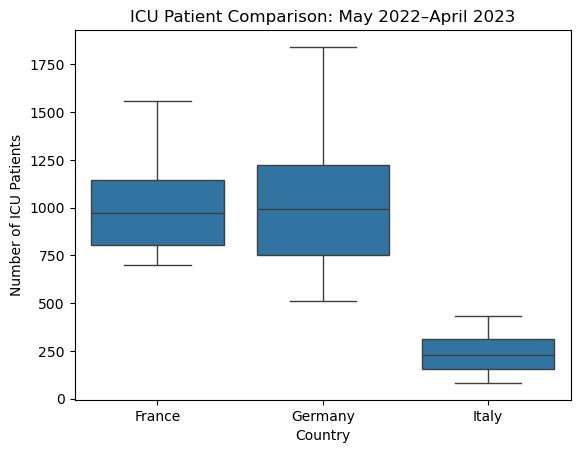

In [13]:
# Filter the data for the required date range
covid_db_may2022_apr2023 = covid_database[(covid_database["date"] >= "2022-05-01") & 
                                                (covid_database["date"] <= "2023-04-30")]

# Filter the data for the required countries 
covid_db_may2022_apr2023_ita_fra_ger = covid_db_may2022_apr2023["location"].isin(["Italy","France","Germany"])
covid_db_may2022_apr2023_ita_fra_ger = covid_db_may2022_apr2023[covid_db_may2022_apr2023_ita_fra_ger]
covid_db_may2022_apr2023_ita_fra_ger.to_csv("covid_db_may2022_apr2023_ita_fra_ger.csv", index=False)

# Analyze ICU patients by country
icu_may2022_apr2023 = covid_db_may2022_apr2023_ita_fra_ger.groupby("location")["icu_patients"].sum()
print("Number of ICU patients by country:")
print(icu_may2022_apr2023)

# Create the box plot
boxplot = sns.boxplot(data = covid_db_may2022_apr2023_ita_fra_ger, x = "location", y = "icu_patients")

plt.title("ICU Patient Comparison: May 2022–April 2023")
plt.xlabel("Country")
plt.ylabel("Number of ICU Patients")

#### 4. Riguardo le nazioni di Italia, Germania e Francia:
           b. brief comment describing the conclusions

The chart shows that France and Germany recorded similar average numbers of ICU patients, both higher than those observed in Italy. The distributions for France and Germany also appear broadly similar.

### 5. For Italy, Germany, France, and Spain throughout 2021:
        a. Show, either graphically or numerically, the sum of hospitalized patients for each country using the hosp_patients column.

Number of hospitalized patients by country:
  location  hosp_patients
0   France      6008717.0
1  Germany            0.0
2    Italy      4419950.0
3    Spain      2411706.0


Text(0, 0.5, 'Number of Hospitalized Patients')

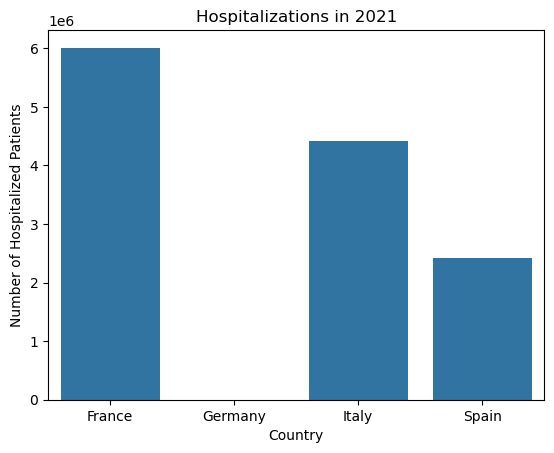

In [14]:
# Filter the data for the required date range
covid_db_2021 = covid_database[(covid_database["date"] >= "2021-01-01") & (covid_database["date"] <= "2021-12-31")]

# Filter the data for the required countries
covid_db_2021_ita_fra_ger_esp = covid_db_2021[covid_db_2021["location"].isin(["Italy","France","Germany","Spain"])]
covid_db_2021_ita_fra_ger_esp.to_csv("covid_db_2021_ita_fra_ger_esp.csv", index=False)

# Calculate the sum of hospitalized patients by country
hosp_patients_2021_ita_fra_ger_esp = (covid_db_2021_ita_fra_ger_esp.groupby("location")
    ["hosp_patients"].sum().reset_index())
print("Number of hospitalized patients by country:")
print(hosp_patients_2021_ita_fra_ger_esp)

# Create the graph
boxplot = sns.barplot(data = hosp_patients_2021_ita_fra_ger_esp, x = "location", y = "hosp_patients")

plt.title("Hospitalizations in 2021")
plt.xlabel("Country")
plt.ylabel("Number of Hospitalized Patients")

In [15]:
# Check for missing values in the four countries

italy_null_hosp_patients_2021 = covid_db_2021[covid_db_2021["location"] == "Italy"]["hosp_patients"].isna().sum()
france_null_hosp_patients_2021 = covid_db_2021[covid_db_2021["location"] == "France"]["hosp_patients"].isna().sum()
germany_null_hosp_patients_2021 = covid_db_2021[covid_db_2021["location"] == "Germany"]["hosp_patients"].isna().sum()
spain_null_hosp_patients_2021 = covid_db_2021[covid_db_2021["location"] == "Spain"]["hosp_patients"].isna().sum()
print(f"Italy: {italy_null_hosp_patients_2021}\nFrance: {france_null_hosp_patients_2021}\nGermany: {germany_null_hosp_patients_2021}\nSpain: {spain_null_hosp_patients_2021}")

Italy: 0
France: 0
Germany: 365
Spain: 0


### 5. For Italy, Germany, France, and Spain throughout 2021:
      b. if there are missing values, briefly explain whether they can be handled through replacement or imputation.

The analysis shows that there are no missing values for France, Spain, or Italy. Germany, however, has 365 missing values, meaning that hospitalization data were not recorded for any day in 2021. Therefore, replacing or imputing these values would not be appropriate, as the data are entirely unavailable for the period considered.